In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
from google.colab import files

uploaded = files.upload()

Saving customer_segmentation_data.csv to customer_segmentation_data.csv


In [13]:
df = pd.read_csv("customer_segmentation_data.csv")

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53503 entries, 0 to 53502
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Customer ID                         53503 non-null  int64 
 1   Age                                 53503 non-null  int64 
 2   Gender                              53503 non-null  object
 3   Marital Status                      53503 non-null  object
 4   Education Level                     53503 non-null  object
 5   Geographic Information              53503 non-null  object
 6   Occupation                          53503 non-null  object
 7   Income Level                        53503 non-null  int64 
 8   Behavioral Data                     53503 non-null  object
 9   Purchase History                    53503 non-null  object
 10  Interactions with Customer Service  53503 non-null  object
 11  Insurance Products Owned            53503 non-null  ob

In [16]:
df.describe()

,Customer ID,Age,Income Level,Coverage Amount,Premium Amount
count,53503.000000,53503.000000,53503.000000,53503.000000,53503.000000
mean,52265.204998,44.140945,82768.324318,492580.789638,3023.702447
std,28165.000067,15.079486,36651.075670,268405.505571,1285.834295
min,1.000000,18.000000,20001.000000,50001.000000,500.000000
25%,28950.500000,32.000000,51568.500000,249613.500000,1817.000000
50%,55858.000000,43.000000,80719.000000,477261.000000,3194.000000
75%,76096.000000,57.000000,115973.500000,739124.000000,4311.500000
max,100000.000000,70.000000,149999.000000,1000000.000000,5000.000000


In [18]:
X = df[['Income Level', 'Age']].values

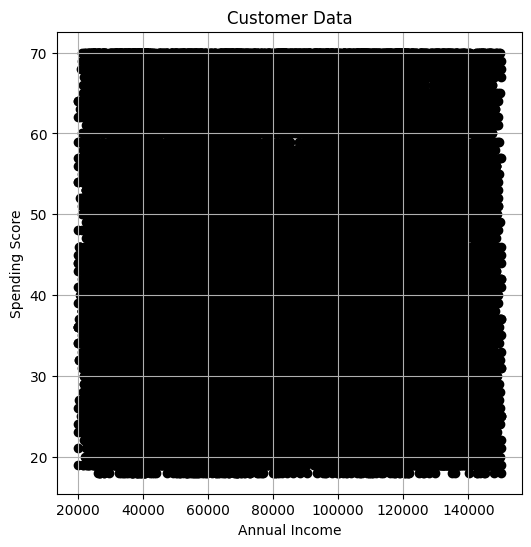

In [20]:
plt.figure(figsize=(6,6))

plt.scatter(X[:,0], X[:,1], color='black')

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Data")

plt.grid(True)
plt.show()

Define Manhattan Distance

In [21]:
def manhattan_distance(a, b):
    return np.abs(a[0]-b[0]) + np.abs(a[1]-b[1])

In [22]:
k = 3

In [23]:
np.random.seed(42)

medoid_indices = np.random.choice(len(X), k, replace=False)

medoids = X[medoid_indices]

print("Initial Medoids:")
print(medoids)

Initial Medoids:
[[ 50891     37]
 [107339     51]
 [ 36083     26]]


In [24]:
def assign_clusters(X, medoids):

    clusters = {}

    for i in range(len(medoids)):
        clusters[i] = []

    for idx, point in enumerate(X):

        distances = []

        for medoid in medoids:
            distances.append(manhattan_distance(point, medoid))

        cluster_id = np.argmin(distances)

        clusters[cluster_id].append(idx)

    return clusters

In [25]:
clusters = assign_clusters(X, medoids)
print(clusters)

{0: [0, 1, 2, 3, 7, 9, 10, 18, 20, 21, 29, 32, 39, 40, 41, 42, 46, 47, 51, 52, 54, 55, 60, 66, 71, 72, 74, 76, 77, 84, 85, 86, 88, 90, 91, 93, 107, 115, 117, 118, 120, 122, 124, 125, 140, 145, 146, 152, 155, 157, 163, 167, 168, 172, 174, 178, 189, 190, 196, 199, 211, 213, 220, 221, 224, 226, 227, 231, 237, 240, 241, 251, 255, 257, 259, 260, 261, 266, 270, 275, 281, 282, 293, 294, 298, 299, 307, 319, 320, 326, 329, 331, 332, 334, 336, 339, 348, 352, 353, 356, 357, 362, 364, 369, 375, 386, 387, 388, 389, 406, 407, 409, 422, 423, 428, 429, 431, 435, 443, 448, 455, 464, 467, 468, 470, 471, 472, 480, 490, 492, 493, 494, 500, 501, 502, 508, 510, 511, 512, 516, 517, 524, 526, 531, 532, 538, 540, 543, 546, 551, 553, 559, 561, 565, 571, 572, 573, 574, 576, 577, 579, 582, 583, 587, 590, 596, 597, 605, 616, 620, 627, 629, 630, 640, 643, 645, 650, 653, 658, 660, 668, 672, 678, 681, 686, 688, 694, 695, 696, 697, 698, 700, 706, 716, 719, 725, 726, 727, 729, 730, 744, 751, 755, 756, 758, 760, 764, 76

In [26]:
def calculate_cost(X, clusters, medoids):

    cost = 0

    for cluster_id in clusters:

        medoid = medoids[cluster_id]

        for point_index in clusters[cluster_id]:

            point = X[point_index]

            cost += manhattan_distance(point, medoid)

    return cost

In [27]:
cost = calculate_cost(X, clusters, medoids)
print("Initial Cost:", cost)

Initial Cost: 699305148


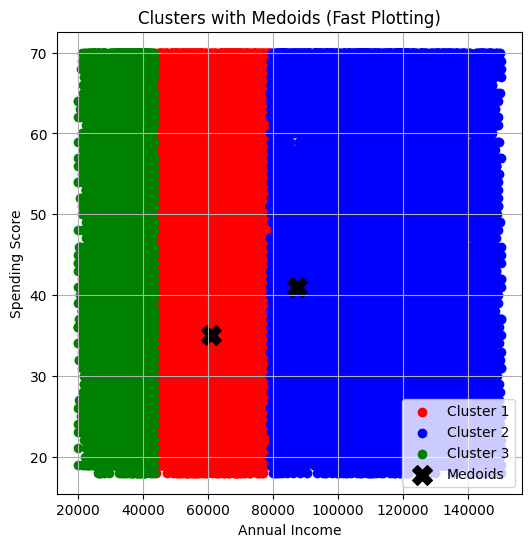

In [29]:
import matplotlib.pyplot as plt
import numpy as np

colors = ['red', 'blue', 'green', 'purple', 'orange']

plt.figure(figsize=(6,6))

# Convert cluster assignments to a numpy array for masking
cluster_assignments = np.zeros(X.shape[0], dtype=int)
for cluster_id, point_indices in clusters.items():
    cluster_assignments[point_indices] = cluster_id

# Plot all clusters at once
for cluster_id in range(len(clusters)):
    mask = (cluster_assignments == cluster_id)
    plt.scatter(X[mask,0], X[mask,1], color=colors[cluster_id], label=f'Cluster {cluster_id+1}')

# Plot medoids
medoid_indices = [5, 7]  # replace with your medoid indices
plt.scatter(X[medoid_indices,0], X[medoid_indices,1], color='black', marker='X', s=200, label='Medoids')

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Clusters with Medoids (Fast Plotting)")
plt.legend()
plt.grid(True)
plt.show()